# Bivariate analysis of categorical variables and the chi-square test

This notebook presents a bivariate analysis of categorical variables, specifically examining the relationship between individuals' countrys of origin, birth years and genders. A chi-square test is employed to determine if there is a statistically significant association between these factors over time. 

The aim is to understand how the geographical distribution of the population has changed over time and whether there is a significant over-representation of female astronomers/physicists in certain countrys.


In [187]:
import pandas as pd

import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import seaborn as sns

In [2]:
### Librairies déjà installées avec Python
import pprint
import csv
import sys

import time
import datetime
from dateutil import parser
from shutil import copyfile


In [3]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

We use in this notebook the data produced in the da2 chapter, i.e. a list of persons with birth year, gender, place of birth, world country of birth

In [73]:
csv_address='da_data/da3-birthYear-gender-country-country.csv'
df_p = pd.read_csv(csv_address)
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,long,lat
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,6.578611,46.060278
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,11.076389,51.464722
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.033056 48.139722),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,23.033056,48.139722
3,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1781,male,Stadthagen,POINT (9.206944 52.324722),http://www.wikidata.org/entity/Q544501,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,9.206944,52.324722
4,http://www.wikidata.org/entity/Q22331669,Carlo Brioschi,1782,male,Milan,POINT (9.19 45.466944),http://www.wikidata.org/entity/Q490,1781-1790,19,Southern Europe,IT,Italia,Italy,ITA,9.190000,45.466944


In [74]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21405 entries, 0 to 21404
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   uriPer      21405 non-null  object 
 1   labelPer    21405 non-null  object 
 2   birthYear   21405 non-null  int64  
 3   gender      21311 non-null  object 
 4   labelPlace  21405 non-null  object 
 5   geometry    21405 non-null  object 
 6   uriPlace    21405 non-null  object 
 7   periods     21405 non-null  object 
 8   FID         21405 non-null  int64  
 9   REGION      21405 non-null  object 
 10  CNTR_ID     21404 non-null  object 
 11  CNTR_NAME   21405 non-null  object 
 12  NAME_ENGL   21405 non-null  object 
 13  ISO3_CODE   21405 non-null  object 
 14  long        21405 non-null  float64
 15  lat         21405 non-null  float64
dtypes: float64(2), int64(2), object(12)
memory usage: 2.6+ MB


## Distribution of countries of birth

In [104]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_country = df_p.groupby('NAME_ENGL').size()
df_country = pd.DataFrame(df_country.sort_values(ascending = False))
df_country.columns=['number']
print(df_country.iloc[:50])
#print(df_country[(df_country.number < 21) & (df_country.number >5)])



                    number
NAME_ENGL                 
Germany               3164
United States         2538
Russian Federation    1958
Italy                 1129
United Kingdom        1121
France                1115
Czechia               1005
Poland                 990
Ukraine                852
Japan                  473
Austria                447
Hungary                429
Spain                  359
Netherlands            335
China                  321
Switzerland            314
India                  307
Estonia                272
Belarus                241
Canada                 237
Romania                228
Lithuania              164
Sweden                 161
Slovenia               155
Georgia                152
Slovakia               150
Belgium                148
Argentina              145
Australia              141
Azerbaijan             135
Denmark                127
Armenia                117
Israel                 113
Finland                113
Brazil                 109
G

In [62]:
print(len(df_p[df_p.NAME_ENGL=='Chile']))
df_p[df_p.NAME_ENGL=='Chile'].head(3)

24


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,long,lat,coded_country,activityYear,per_25
2115,http://www.wikidata.org/entity/Q24262108,Arturo Salazar,1855,male,Andacollo,POINT (-71.083333 -30.216667),http://www.wikidata.org/entity/Q3602,1851-1860,15,South America,CL,Chile,Chile,CHL,-71.083333,-30.216667,Chile,1900,1876-1900
4585,http://www.wikidata.org/entity/Q2782343,Carlos Segers,1900,male,Chile,POINT (-71 -33),http://www.wikidata.org/entity/Q298,1891-1900,15,South America,CL,Chile,Chile,CHL,-71.000000,-33.000000,Chile,1945,1926-1950
7312,http://www.wikidata.org/entity/Q360832,Nicanor Parra,1914,male,San Fabián,POINT (-71.55 -36.55),http://www.wikidata.org/entity/Q187795,1911-1920,15,South America,CL,Chile,Chile,CHL,-71.550000,-36.550000,Chile,1959,1951-1975


In [173]:
### We define a function that codes and aggregates the values in order to avoid dispersion, 
# which would make them difficult to analyse.

def codeCountry(country: str):
    if 'Russian Federation' in country \
        or 'Kazakhstan' in country \
        or 'Georgia' in country \
        or 'Uzbekistan' in country \
        or 'Armenia' in country \
        or 'Azerbaijan' in country:
        output='Russian Federation'
    elif 'Estonia' in country \
        or 'Latvia' in country \
        or 'Finland' in country \
        or 'Belarus' in country \
        or 'Lithuania' in country:
        output='Baltic States Fin. Belar.'
    elif 'Moldova' in country \
        or 'Serbia' in country \
        or 'Slovenia' in country \
        or 'Slovakia' in country \
        or 'Romania' in country \
        or 'Croatia' in country \
        or 'Bulgaria' in country:
        output='Central Europe'
    elif 'Norway' in country \
        or 'Denmark' in country \
        or 'Sweden' in country:
        output='Scandinavia'
    elif 'Argentina' in country \
        or 'Brazil' in country \
        or 'Chile' in country:
        output='South America'    
    elif 'Spain' in country \
        or 'Portugal' in country:
        output='Spain Port.'    
    elif 'Belgium' in country \
        or 'Netherlands' in country:
        output='Belgium Nether.'   
    elif 'Australia' in country \
        or 'New Zealand' in country:
        output='Australia New Z.'      
    elif 'Canada' in country \
        or 'United States' in country:
        output='United States Can.'   
    elif 'Austria' in country \
        or 'Hungary' in country:
        output='Austria Hungary'       
    else:
        output=country
    return output                   

In [174]:
### Test the function
r='Belgium'
#r='Latvia'
codeCountry(r)

'Belgium Nether.'

In [175]:
### Create a new column with the coded values
df_p['coded_country']=df_p.NAME_ENGL.apply(lambda x : codeCountry(x))

In [188]:
### Group and count
df_country = df_p.groupby('coded_country').size()
df_country = pd.DataFrame(df_country.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_country.columns=['number']
df_country_100 = df_country[df_country.number > 200]
print(len(df_country_100))

20


In [189]:
df_country_100

,number
coded_country,
Germany,3164
United States Can.,2775
Russian Federation,2491
Italy,1129
United Kingdom,1121
France,1115
Czechia,1005
Poland,990
Austria Hungary,876


### Transform birth years to periods of activity years

In [190]:
### Create imputed activity year
df_p['activityYear'] = df_p.birthYear.apply(lambda x : int(x)+45)

In [191]:
### Create list of 25 years periods

yr = df_p.activityYear

l_25 = list(range(min(yr), max(yr)+51, 25))
print(l_25[:5],l_25[-5:], len(l_25)-1)

[1826, 1851, 1876, 1901, 1926] [1951, 1976, 2001, 2026, 2051] 9


In [192]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# A new column is added containing the period, based on the previous list and the year value

df_p['per_25'] = pd.cut(df_p['activityYear'], l_25, right=False)

### Rewrite the added code to make it more readable
df_p['per_25'] = df_p['per_25'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,long,lat,coded_country,activityYear,per_25
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,6.578611,46.060278,France,1831,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,11.076389,51.464722,Germany,1827,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.033056 48.139722),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,23.033056,48.139722,Ukraine,1834,1826-1850


In [193]:
### Distribution of activities by 25 years periods
activities_per = pd.DataFrame(df_p.groupby(by='per_25').size())
activities_per.columns=['number']
print(activities_per)

           number
per_25           
1826-1850     407
1851-1875     574
1876-1900     948
1901-1925    1461
1926-1950    2308
1951-1975    4942
1976-2000    7254
2001-2025    3511
2026-2050       0


## Bivariate analysis

* A contingency table organises data to show the frequency of two or more categorical variables arranged in rows and columns, revealing possible relationships between them.
* Frequency counts are produced by calculating how often each combination of categories occurs in the dataset.

In [194]:
lcc = df_country_100.index.to_list()
lcc

['Germany',
 'United States Can.',
 'Russian Federation',
 'Italy',
 'United Kingdom',
 'France',
 'Czechia',
 'Poland',
 'Austria Hungary',
 'Baltic States Fin. Belar.',
 'Ukraine',
 'Central Europe',
 'Belgium Nether.',
 'Japan',
 'Spain Port.',
 'Scandinavia',
 'China',
 'Switzerland',
 'India',
 'South America']

In [195]:
df_pcc = df_p[df_p.coded_country.isin(lcc)]
df_pcc.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,long,lat,coded_country,activityYear,per_25
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,6.578611,46.060278,France,1831,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,11.076389,51.464722,Germany,1827,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.033056 48.139722),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,23.033056,48.139722,Ukraine,1834,1826-1850
3,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1781,male,Stadthagen,POINT (9.206944 52.324722),http://www.wikidata.org/entity/Q544501,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,9.206944,52.324722,Germany,1826,1826-1850
4,http://www.wikidata.org/entity/Q22331669,Carlo Brioschi,1782,male,Milan,POINT (9.19 45.466944),http://www.wikidata.org/entity/Q490,1781-1790,19,Southern Europe,IT,Italia,Italy,ITA,9.190000,45.466944,Italy,1827,1826-1850


In [244]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_country=pd.crosstab(df_pcc.per_25, df_pcc.coded_country, margins=True)

## display all columns
pd.set_option('display.max_columns', None)

per_vs_country.iloc[2:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Nether.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
per_25,,,,,,,,,,,,,,,,,,,,,
1876-1900,47,22,31,25,0,53,110,180,3,61,4,46,51,26,5,17,27,16,103,87,914
1901-1925,67,35,33,52,1,60,144,277,3,90,18,66,107,41,5,31,32,45,106,204,1417
1926-1950,123,55,70,75,16,92,144,388,15,88,43,116,260,68,13,35,43,111,134,335,2224
1951-1975,219,179,107,178,100,184,199,650,63,165,144,195,679,69,51,42,64,260,276,878,4702
1976-2000,258,393,117,311,128,360,262,870,162,315,173,386,1072,88,113,109,73,339,276,910,6715
2001-2025,132,159,92,141,73,220,114,601,57,317,90,127,291,46,87,138,47,69,102,296,3199
All,876,867,483,805,321,1005,1115,3164,307,1129,473,990,2491,378,278,381,314,852,1121,2775,20125


In [246]:
observed = per_vs_country.iloc[2:-1, :-1 ]
observed

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Nether.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.
per_25,,,,,,,,,,,,,,,,,,,,
1876-1900,47,22,31,25,0,53,110,180,3,61,4,46,51,26,5,17,27,16,103,87
1901-1925,67,35,33,52,1,60,144,277,3,90,18,66,107,41,5,31,32,45,106,204
1926-1950,123,55,70,75,16,92,144,388,15,88,43,116,260,68,13,35,43,111,134,335
1951-1975,219,179,107,178,100,184,199,650,63,165,144,195,679,69,51,42,64,260,276,878
1976-2000,258,393,117,311,128,360,262,870,162,315,173,386,1072,88,113,109,73,339,276,910
2001-2025,132,159,92,141,73,220,114,601,57,317,90,127,291,46,87,138,47,69,102,296


In [249]:
### Calculation of parameters for the chi-square test
statistic, p, dof, expected = stats.chi2_contingency(observed)


In [250]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))


Degrees of freedom: 95 ; Chi-square value: 1615.52


In [251]:
### P-value
print('p-value :', p)

p-value : 6.804285816268964e-275


In [252]:
### Cramér's V (normalized phi) coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(per_vs_country_min50, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.1242875588123276


In [253]:
### Using statmodels (sm)

# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
adjusted_resids.round(1)

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Nether.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.
per_25,,,,,,,,,,,,,,,,,,,,
1876-1900,1.1,-3.0,2.1,-2.1,-3.9,1.0,9.8,3.6,-3.1,1.7,-4.0,0.2,-6.7,2.5,-2.3,-0.2,3.7,-4.0,8.5,-4.1
1901-1925,0.6,-3.7,-0.0,-0.8,-4.9,-1.5,9.1,4.4,-4.3,1.6,-3.0,-0.4,-6.2,3.4,-3.5,0.7,2.5,-2.3,4.0,0.3
1926-1950,2.7,-4.7,2.7,-1.8,-3.7,-2.1,3.2,2.7,-3.6,-3.2,-1.7,0.8,-1.7,4.9,-3.6,-1.3,1.8,1.5,1.9,1.3
1951-1975,0.9,-2.3,-0.4,-1.2,2.9,-4.1,-3.0,-3.6,-1.5,-6.6,3.1,-2.7,3.8,-1.8,-2.3,-6.0,-0.9,4.4,2.4,10.3
1976-2000,-2.8,7.2,-4.1,2.8,1.9,1.4,-5.4,-7.1,6.8,-3.2,0.8,4.1,9.5,-3.5,2.2,-2.3,-3.4,3.3,-5.0,-1.7
2001-2025,-0.9,1.7,2.2,1.0,3.0,5.2,-4.3,5.7,1.0,12.3,1.4,-2.6,-6.9,-1.5,6.7,10.7,-0.1,-6.7,-5.6,-8.7


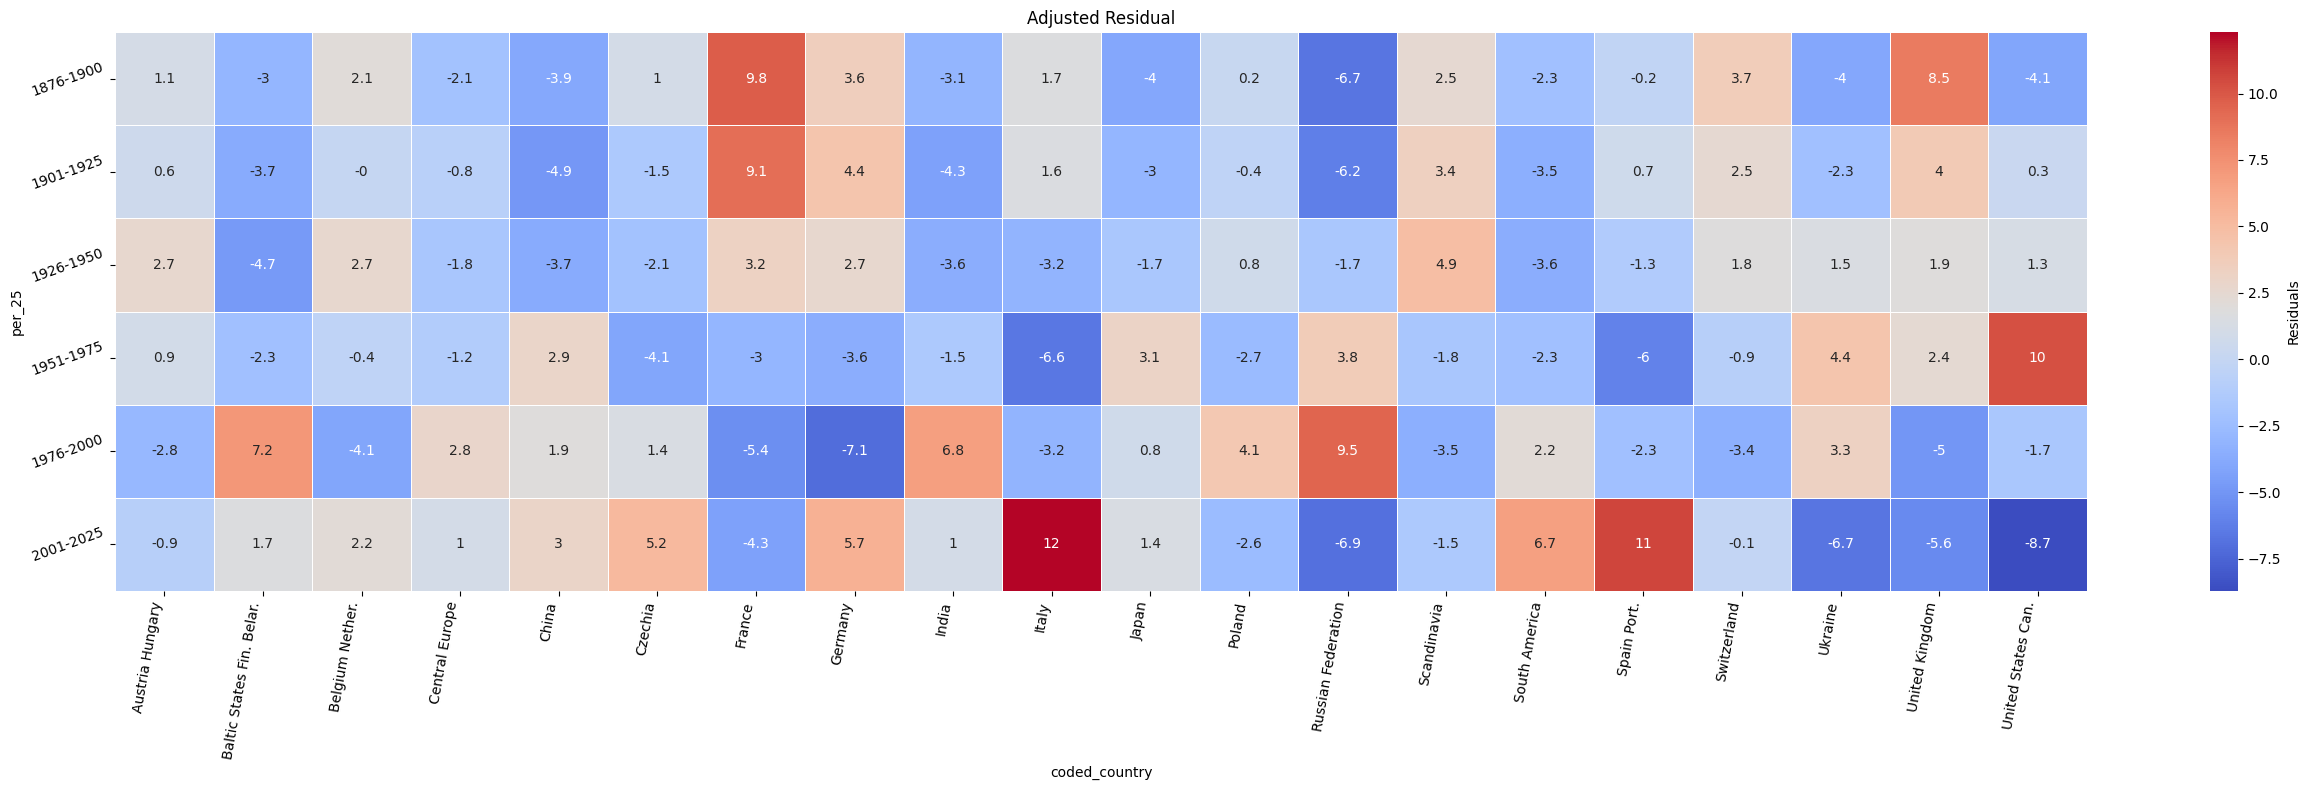

In [254]:
### Plot the residuals

# 3. Plot
fig, ax = plt.subplots(1,1,figsize=(26,8))         


# Create heatmap
sns.heatmap(
    adjusted_resids.round(1), 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')
ax.set_title("Adjusted Residual", fontsize=12)

# ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.tight_layout()
plt.show()

In [255]:
per_vs_country.iloc[2:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Nether.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
per_25,,,,,,,,,,,,,,,,,,,,,
1876-1900,47,22,31,25,0,53,110,180,3,61,4,46,51,26,5,17,27,16,103,87,914
1901-1925,67,35,33,52,1,60,144,277,3,90,18,66,107,41,5,31,32,45,106,204,1417
1926-1950,123,55,70,75,16,92,144,388,15,88,43,116,260,68,13,35,43,111,134,335,2224
1951-1975,219,179,107,178,100,184,199,650,63,165,144,195,679,69,51,42,64,260,276,878,4702
1976-2000,258,393,117,311,128,360,262,870,162,315,173,386,1072,88,113,109,73,339,276,910,6715
2001-2025,132,159,92,141,73,220,114,601,57,317,90,127,291,46,87,138,47,69,102,296,3199
All,876,867,483,805,321,1005,1115,3164,307,1129,473,990,2491,378,278,381,314,852,1121,2775,20125


## Bivariate analysis genders

In [208]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_pcc[df_pcc['gender'].isin(['female', 'male'])]

In [211]:
gender_vs_country=pd.crosstab(df_pg.gender, df_pg.coded_country, margins=True)
gender_vs_country

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Nether.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
gender,,,,,,,,,,,,,,,,,,,,,
female,79,54,29,72,30,62,81,147,25,98,6,72,124,28,54,68,10,60,93,299,1491
male,796,812,451,727,285,943,1034,3011,281,1030,453,918,2334,349,223,313,304,791,1027,2470,18552
All,875,866,480,799,315,1005,1115,3158,306,1128,459,990,2458,377,277,381,314,851,1120,2769,20043


In [212]:
### All the period but with less countrys
# X_reg_all_period = per_vs_country.loc[:, per_vs_country.iloc[-1] > 500].iloc[:-1, :-1 ]
X = gender_vs_country.iloc[:-1, :-1 ]

In [213]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [214]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 271.0129857787174 , dof : 19
p-value : 1.6719947361070301e-46


In [215]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.11628231979307295


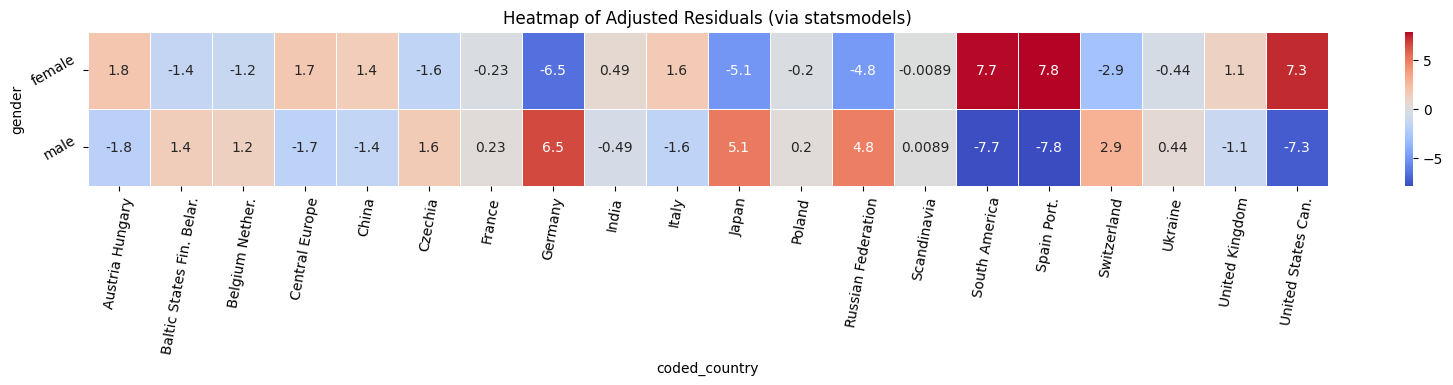

In [218]:
# 1. Create the Table object directly from your data
table = sm.stats.Table(X)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(20,2))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


We can observe that women are more present in some countries. The difference is statistically relevant although weak: Cramer's V = 0.116

In [228]:
lc=X.columns.to_list()
lc

['Austria Hungary',
 'Baltic States Fin. Belar.',
 'Belgium Nether.',
 'Central Europe',
 'China',
 'Czechia',
 'France',
 'Germany',
 'India',
 'Italy',
 'Japan',
 'Poland',
 'Russian Federation',
 'Scandinavia',
 'South America',
 'Spain Port.',
 'Switzerland',
 'Ukraine',
 'United Kingdom',
 'United States Can.']

## Bivariate analysis genders+generations vs countrys

In [256]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_pcc[df_pcc['gender'].isin(['female', 'male'])]
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,long,lat,coded_country,activityYear,per_25
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,6.578611,46.060278,France,1831,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,11.076389,51.464722,Germany,1827,1826-1850


In [257]:
def code_gender_period(gender: str):
    if gender == 'female':
        output='f'
    else:
        output='m'
    return output    

In [258]:
df_pg['per_gender']= df_pg.apply(lambda x: x.per_25 +'_'+ code_gender_period(x.gender), axis=1)
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,long,lat,coded_country,activityYear,per_25,per_gender
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,6.578611,46.060278,France,1831,1826-1850,1826-1850_m
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,11.076389,51.464722,Germany,1827,1826-1850,1826-1850_m


In [259]:
per_gender_vs_country=pd.crosstab(df_pg.per_gender, df_pg.coded_country, margins=True)
per_gender_vs_country.iloc[6:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Nether.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
per_gender,,,,,,,,,,,,,,,,,,,,,
1901-1925_f,4,0,0,2,0,1,1,3,0,0,0,2,4,4,0,0,0,2,11,29,63
1901-1925_m,63,35,33,50,1,59,143,274,3,90,17,64,103,37,5,31,32,43,95,175,1353
1926-1950_f,16,1,5,4,0,5,17,18,1,10,0,6,18,3,2,3,0,5,12,48,174
1926-1950_m,107,54,64,70,14,87,127,369,14,78,40,110,241,65,11,32,43,106,122,287,2041
1951-1975_f,23,7,2,16,11,7,16,26,4,13,1,19,35,4,9,9,3,13,18,72,308
1951-1975_m,196,172,105,162,89,177,183,624,59,152,142,176,640,65,42,33,61,247,258,804,4387
1976-2000_f,18,25,7,27,9,23,29,29,9,20,2,36,38,7,17,13,1,29,23,71,433
1976-2000_m,239,367,110,280,115,337,233,839,153,294,166,350,1016,81,95,96,72,309,253,837,6242
2001-2025_f,18,21,14,23,10,25,18,71,10,54,3,9,27,10,26,43,6,11,18,70,487


In [267]:
### All the period but with less countrys
# X_reg_all_period = per_vs_country.loc[:, per_vs_country.iloc[-1] > 500].iloc[:-1, :-1 ]
observed = per_gender_vs_country.iloc[6:-1, :-1 ]

In [268]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(observed)


In [269]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
dfe = pd.DataFrame(expected).round(0)
dfe.index = X.index
dfe.columns = X.columns
dfe

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Nether.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.
per_gender,,,,,,,,,,,,,,,,,,,,
1901-1925_f,3.0,3.0,1.0,3.0,1.0,3.0,3.0,10.0,1.0,3.0,2.0,3.0,8.0,1.0,1.0,1.0,1.0,3.0,3.0,9.0
1901-1925_m,59.0,61.0,31.0,56.0,23.0,68.0,64.0,207.0,22.0,73.0,34.0,66.0,177.0,23.0,20.0,26.0,19.0,61.0,66.0,195.0
1926-1950_f,8.0,8.0,4.0,7.0,3.0,9.0,8.0,27.0,3.0,9.0,4.0,9.0,23.0,3.0,3.0,3.0,2.0,8.0,9.0,25.0
1926-1950_m,90.0,92.0,47.0,84.0,35.0,103.0,97.0,312.0,34.0,109.0,51.0,100.0,267.0,35.0,30.0,40.0,29.0,92.0,100.0,294.0
1951-1975_f,14.0,14.0,7.0,13.0,5.0,16.0,15.0,47.0,5.0,17.0,8.0,15.0,40.0,5.0,5.0,6.0,4.0,14.0,15.0,44.0
1951-1975_m,193.0,198.0,101.0,181.0,75.0,221.0,208.0,671.0,72.0,235.0,110.0,215.0,573.0,75.0,65.0,86.0,63.0,199.0,216.0,632.0
1976-2000_f,19.0,20.0,10.0,18.0,7.0,22.0,21.0,66.0,7.0,23.0,11.0,21.0,57.0,7.0,6.0,8.0,6.0,20.0,21.0,62.0
1976-2000_m,274.0,282.0,143.0,258.0,107.0,315.0,296.0,955.0,103.0,334.0,156.0,306.0,816.0,107.0,92.0,122.0,89.0,283.0,307.0,899.0
2001-2025_f,21.0,22.0,11.0,20.0,8.0,25.0,23.0,74.0,8.0,26.0,12.0,24.0,64.0,8.0,7.0,10.0,7.0,22.0,24.0,70.0


If we apply the rule of thumb presented above, we observe that there can be issues with the chi-square test

In [270]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 1721.48811560484 , dof : 171
p-value : 5.505812525001499e-254


In [271]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.10258446614463909


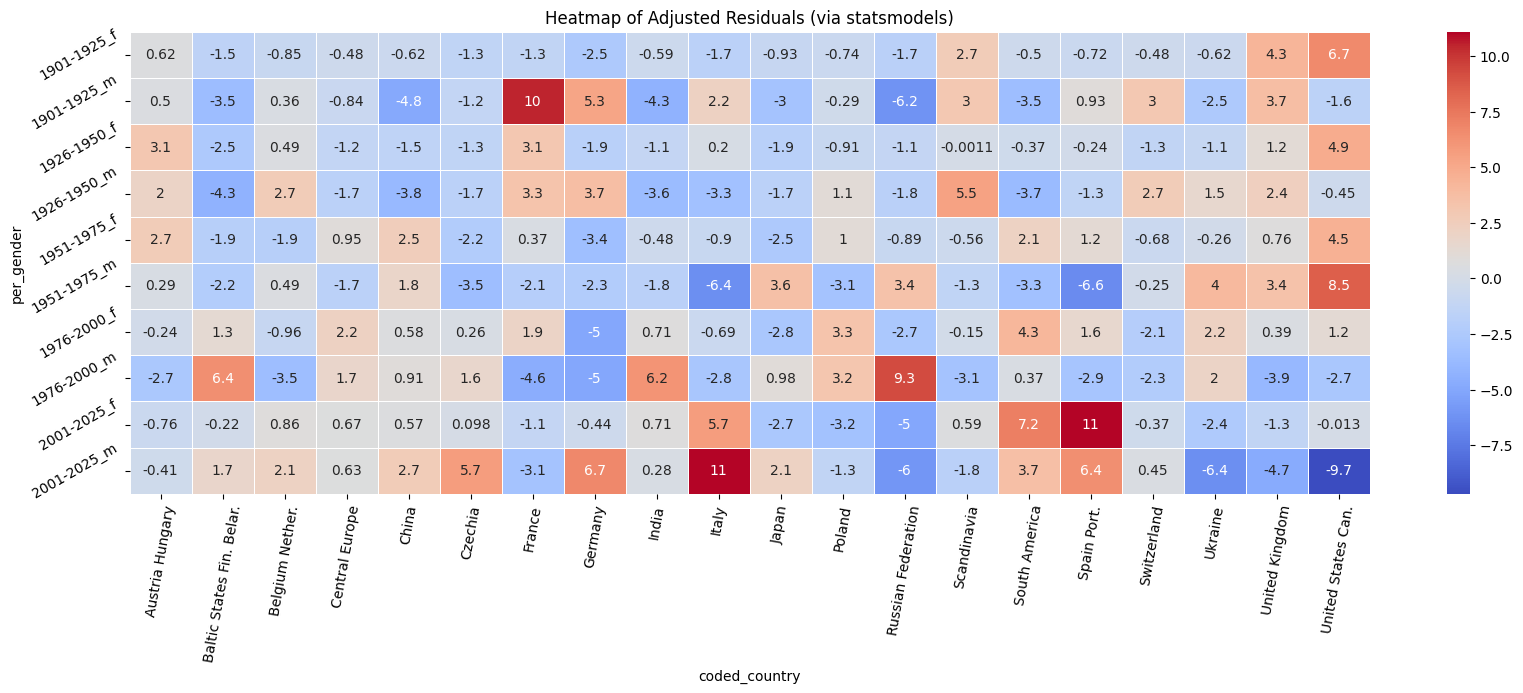

In [273]:
# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(20,6))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


In [274]:
dfs = df_pg[(df_pg.per_gender.isin(['2001-2025_f']))&(df_pg.coded_country.isin(['South America', 'Spain Port.']))]
print(len(dfs))

69


In [242]:
dfs.head(10)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,long,lat,coded_country,activityYear,per_25,per_gender
17031,http://www.wikidata.org/entity/Q121890944,Isabel Hawkins,1958,female,Córdoba,POINT (-64.183333 -31.416667),http://www.wikidata.org/entity/Q44210,1951-1960,15,South America,AR,Argentina,Argentina,ARG,-64.183333,-31.416667,South America,2003,2001-2025,2001-2025_f
17428,http://www.wikidata.org/entity/Q3442245,Rosaly Lopes,1957,female,Rio de Janeiro,POINT (-43.205555 -22.911111),http://www.wikidata.org/entity/Q8678,1951-1960,15,South America,BR,Brasil,Brazil,BRA,-43.205555,-22.911111,South America,2002,2001-2025,2001-2025_f
18317,http://www.wikidata.org/entity/Q61718357,María Teresa Dova,1959,female,Alberti,POINT (-60.266667 -35.016667),http://www.wikidata.org/entity/Q940887,1951-1960,15,South America,AR,Argentina,Argentina,ARG,-60.266667,-35.016667,South America,2004,2001-2025,2001-2025_f
18338,http://www.wikidata.org/entity/Q19812690,Josefa Masegosa Gallego,1957,female,Oria,POINT (-2.292294 37.483965),http://www.wikidata.org/entity/Q1444097,1951-1960,19,Southern Europe,ES,España,Spain,ESP,-2.292294,37.483965,Spain Port.,2002,2001-2025,2001-2025_f
18344,http://www.wikidata.org/entity/Q19766208,Teresa Rodrigo Anoro,1956,female,Almacelles,POINT (0.437057 41.731689),http://www.wikidata.org/entity/Q1626921,1951-1960,19,Southern Europe,ES,España,Spain,ESP,0.437057,41.731689,Spain Port.,2001,2001-2025,2001-2025_f
18530,http://www.wikidata.org/entity/Q62072509,Judith Desimoni,1956,female,Olavarría,POINT (-60.333333 -36.9),http://www.wikidata.org/entity/Q1004149,1951-1960,15,South America,AR,Argentina,Argentina,ARG,-60.333333,-36.900000,South America,2001,2001-2025,2001-2025_f
18595,http://www.wikidata.org/entity/Q6757087,Marcia Barbosa,1960,female,Rio de Janeiro,POINT (-43.205555 -22.911111),http://www.wikidata.org/entity/Q8678,1951-1960,15,South America,BR,Brasil,Brazil,BRA,-43.205555,-22.911111,South America,2005,2001-2025,2001-2025_f
18722,http://www.wikidata.org/entity/Q55704831,Sonia Guimarães,1957,female,Brotas,POINT (-48.126944 -22.283889),http://www.wikidata.org/entity/Q1648408,1951-1960,15,South America,BR,Brasil,Brazil,BRA,-48.126944,-22.283889,South America,2002,2001-2025,2001-2025_f
19223,http://www.wikidata.org/entity/Q60758204,María Luisa Sarsa,1968,female,Zaragoza,POINT (-0.883333 41.65),http://www.wikidata.org/entity/Q10305,1961-1970,19,Southern Europe,ES,España,Spain,ESP,-0.883333,41.650000,Spain Port.,2013,2001-2025,2001-2025_f
19231,http://www.wikidata.org/entity/Q16843449,Gabriela González,1965,female,Córdoba,POINT (-64.183333 -31.416667),http://www.wikidata.org/entity/Q44210,1961-1970,15,South America,AR,Argentina,Argentina,ARG,-64.183333,-31.416667,South America,2010,2001-2025,2001-2025_f


### Inspected persons

* [Josefa Masegosa Gallego](http://www.wikidata.org/entity/Q19812690) (Spain)
* [Judith Desimoni](http://www.wikidata.org/entity/Q62072509) (Argentina)